In [2]:
import requests
from dotenv import load_dotenv
import os

In [3]:

load_dotenv()

url = "https://api.dataforsyningen.dk/dhm_wcs_DAF"
params = {
    "service": "WCS",
    "version": "1.0.0",
    "request": "DescribeCoverage",
    "coverage": "dhm_terraen",
    "token": os.getenv("DATATOKEN")
}

response = requests.get(url, params=params)

print(response.text)

<?xml version="1.0" encoding="utf-8"?>
<CoverageDescription xmlns="http://www.opengis.net/wcs" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns:gml="http://www.opengis.net/gml" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" version="1.0.0" updateSequence="0" xsi:schemaLocation="http://www.opengis.net/wcs http://schemas.opengis.net/wcs/1.0.0/describeCoverage.xsd">
  <CoverageOffering>
    <name>dhm_terraen</name>
    <label>dhm_terraen</label>
    <lonLatEnvelope srsName="urn:ogc:def:crs:OGC:1.3:CRS84">
      <gml:pos>8.00830949937517 54.4354651516217</gml:pos>
      <gml:pos>15.5979112056959 57.7690657013977</gml:pos>
    </lonLatEnvelope>
    <domainSet>
      <spatialDomain>
        <gml:Envelope srsName="EPSG:4326">
          <gml:pos>8.00830949937517 54.4354651516217</gml:pos>
          <gml:pos>15.5979112056959 57.7690657013977</gml:pos>
        </gml:Envelope>
        <gml:Envelope srsName="epsg:25832">
          <gml:pos>441000 6049000</gml:pos>
          <gml:pos>894000 

In [4]:
load_dotenv()

url = "https://api.dataforsyningen.dk/dhm_wcs_DAF"
params = {
    "service": "WCS",
    "request": "GetCapabilities",
    "token": os.getenv("DATATOKEN")
}

response = requests.get(url, params=params)

print(response.text)


<?xml version="1.0" encoding="utf-8"?>
<WCS_Capabilities xmlns="http://www.opengis.net/wcs" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns:gml="http://www.opengis.net/gml" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" version="1.0.0" xsi:schemaLocation="http://www.opengis.net/wcs http://schemas.opengis.net/wcs/1.0.0/wcsCapabilities.xsd">
  <Service>
    <name>DTM</name>
    <label>wcs_label_web</label>
    <fees>NONE</fees>
    <accessConstraints>
    NONE
  </accessConstraints>
  </Service>
  <Capability>
    <Request>
      <GetCapabilities>
        <DCPType>
          <HTTP>
            <Get>
              <OnlineResource xlink:type="simple" xlink:href="https://api.dataforsyningen.dk/dhm_wcs_DAF?token=7b8b57a36691b0b37ed1e4db995e1429&amp;"/>
            </Get>
          </HTTP>
        </DCPType>
      </GetCapabilities>
      <DescribeCoverage>
        <DCPType>
          <HTTP>
            <Get>
              <OnlineResource xlink:type="simple" xlink:href="https://api.da

In [5]:
load_dotenv()
print(os.getenv("DATATOKEN"))

7b8b57a36691b0b37ed1e4db995e1429


In [ ]:
# area:
# <gml:pos>441000 6049000</gml:pos> (lower left)
# <gml:pos>894000 6403000</gml:pos> (upper right)
# "bbox": "441000,6049000,894000,6403000" 
load_dotenv()

url = "https://api.dataforsyningen.dk/dhm_wcs_DAF"
params = {
    "service": "WCS",
    "version": "1.0.0",
    "request": "GetCoverage",
    "coverage": "dhm_terraen",   # from XML
    "crs": "EPSG:25832",                    # verify in DescribeCoverage
    "bbox": "493000,6102000,494000,6103000",# must be valid area
    "width": "1000",
    "height": "1000",
    "format": "GTiff",
    "token": os.getenv("DATATOKEN")
}
load_dotenv()
response = requests.get(url, params=params)

with open("dem_tile_better_res.tif", "wb") as f:
    f.write(response.content)

print("Saved dem_tile_better_res.tif")

Saved dem_tile_better_res.tif


In [29]:
# area:
# <gml:pos>441000 6049000</gml:pos>
# <gml:pos>894000 6403000</gml:pos>
load_dotenv()

url = "https://api.dataforsyningen.dk/dhm_wcs_DAF"
params = {
    "service": "WCS",
    "version": "1.0.0",
    "request": "GetCoverage",
    "coverage": "dhm_terraen",   # from XML
    "crs": "EPSG:25832",                    # verify in DescribeCoverage
    "bbox": "441000,6049000,594000,6403000" ,
    "width": "500",
    "height": "500",
    "format": "GTiff",
    "token": os.getenv("DATATOKEN")
}
load_dotenv()
response = requests.get(url, params=params)

with open("dem_tile.tif", "wb") as f:
    f.write(response.content)

print("Saved dem_tile.tif")

Saved dem_tile.tif


In [30]:
import rasterio

with rasterio.open("dem_tile.tif") as src:
    dem = src.read(1)
    print(dem.shape)
    print(dem.min(), dem.max())


(500, 500)
-2.5842335 162.8089


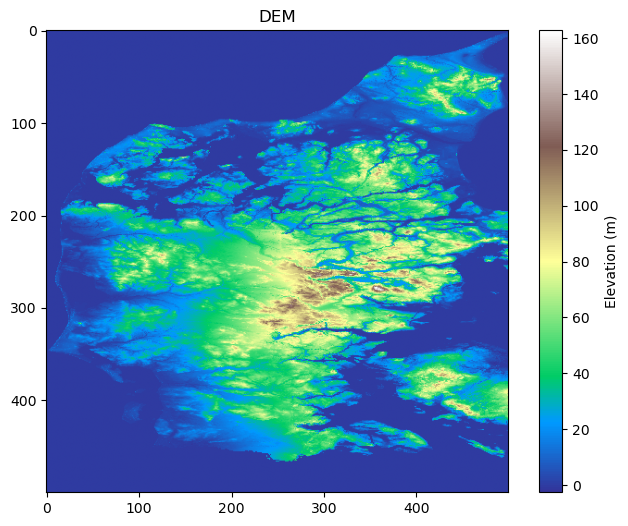

In [31]:
import matplotlib.pyplot as plt
import rasterio

plt.figure(figsize=(8, 6))
plt.imshow(dem, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("DEM")
plt.show()


In [10]:
import copy
import os
import random
import shutil
import zipfile
from math import atan2, cos, sin, sqrt, pi, log

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
from numpy import linalg as LA
from torch import optim, nn
from torch.utils.data import DataLoader, random_split
from torch.utils.data.dataset import Dataset
from torchvision import transforms
from tqdm import tqdm

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)
    

class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)

        return down, p
    
class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x1, x2], 1)
        return self.conv(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)

        self.bottle_neck = DoubleConv(512, 1024)

        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)
        self.up_convolution_5 = UpSample(64, 32)
        self.up_convolution_6 = UpSample(32,16)
        
        self.first_up_convolution_1 = nn.ConvTranspose2d(in_channels, 32, kernel_size=2, stride=2)

        self.out = nn.Conv2d(in_channels=16, out_channels=num_classes, kernel_size=1)

    def forward(self, x):

        first_1 = self.first_up_convolution_1(x)

        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4)

        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)
        up_5 = self.up_convolution_5(up_4,first_1)

        out = self.out(up_5)
        return out

In [13]:
transform = transforms.Compose([
            transforms.ToTensor()])

tensor = transform(Image.open("dem_tile.tif"))
print(tensor.shape)

torch.Size([1, 512, 512])


In [14]:
model = UNet(1,1)
output = model(tensor.unsqueeze(0))  # Add batch dimension
print(output.size())
# You should get torch.Size([1, 10, 512, 512]) as a result ..not!

torch.Size([1, 1, 2048, 2048])


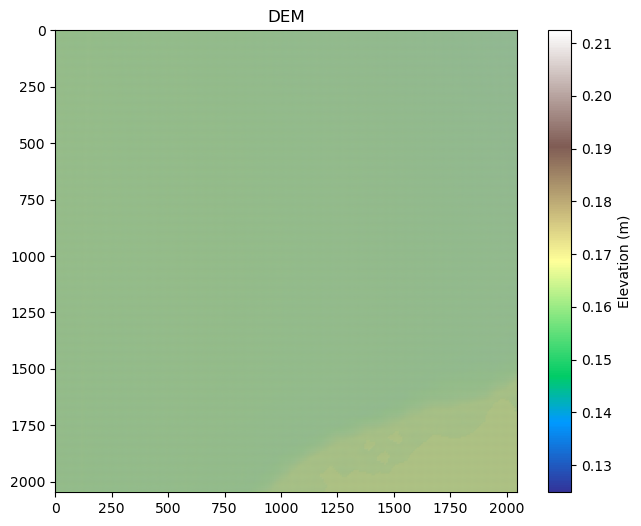

In [15]:
DEM_output= output.detach().numpy().squeeze()
plt.figure(figsize=(8, 6))
plt.imshow(DEM_output, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("DEM")
plt.show()

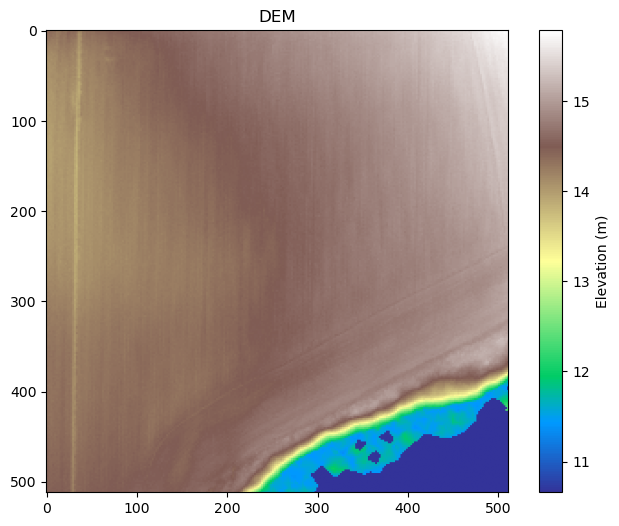

In [16]:
plt.figure(figsize=(8, 6))
plt.imshow(tensor.detach().numpy().squeeze(), cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("DEM")
plt.show()